<a href="https://colab.research.google.com/github/YeluriSahithi06/house-price-estimator/blob/main/house_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas scikit-learn gradio numpy

📊 Generating Exploratory Data Analysis Plots...


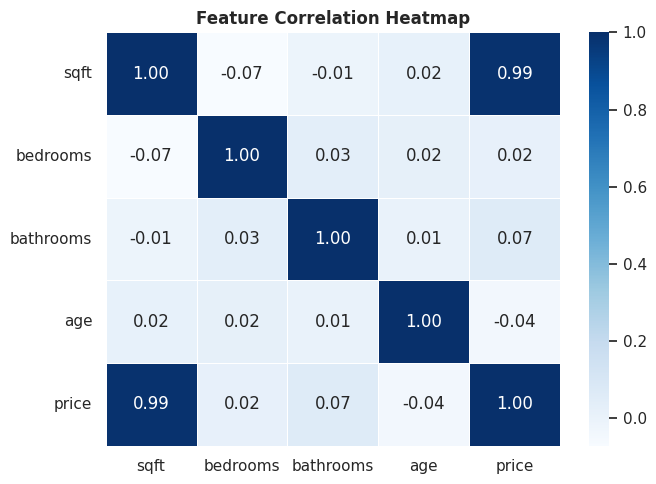

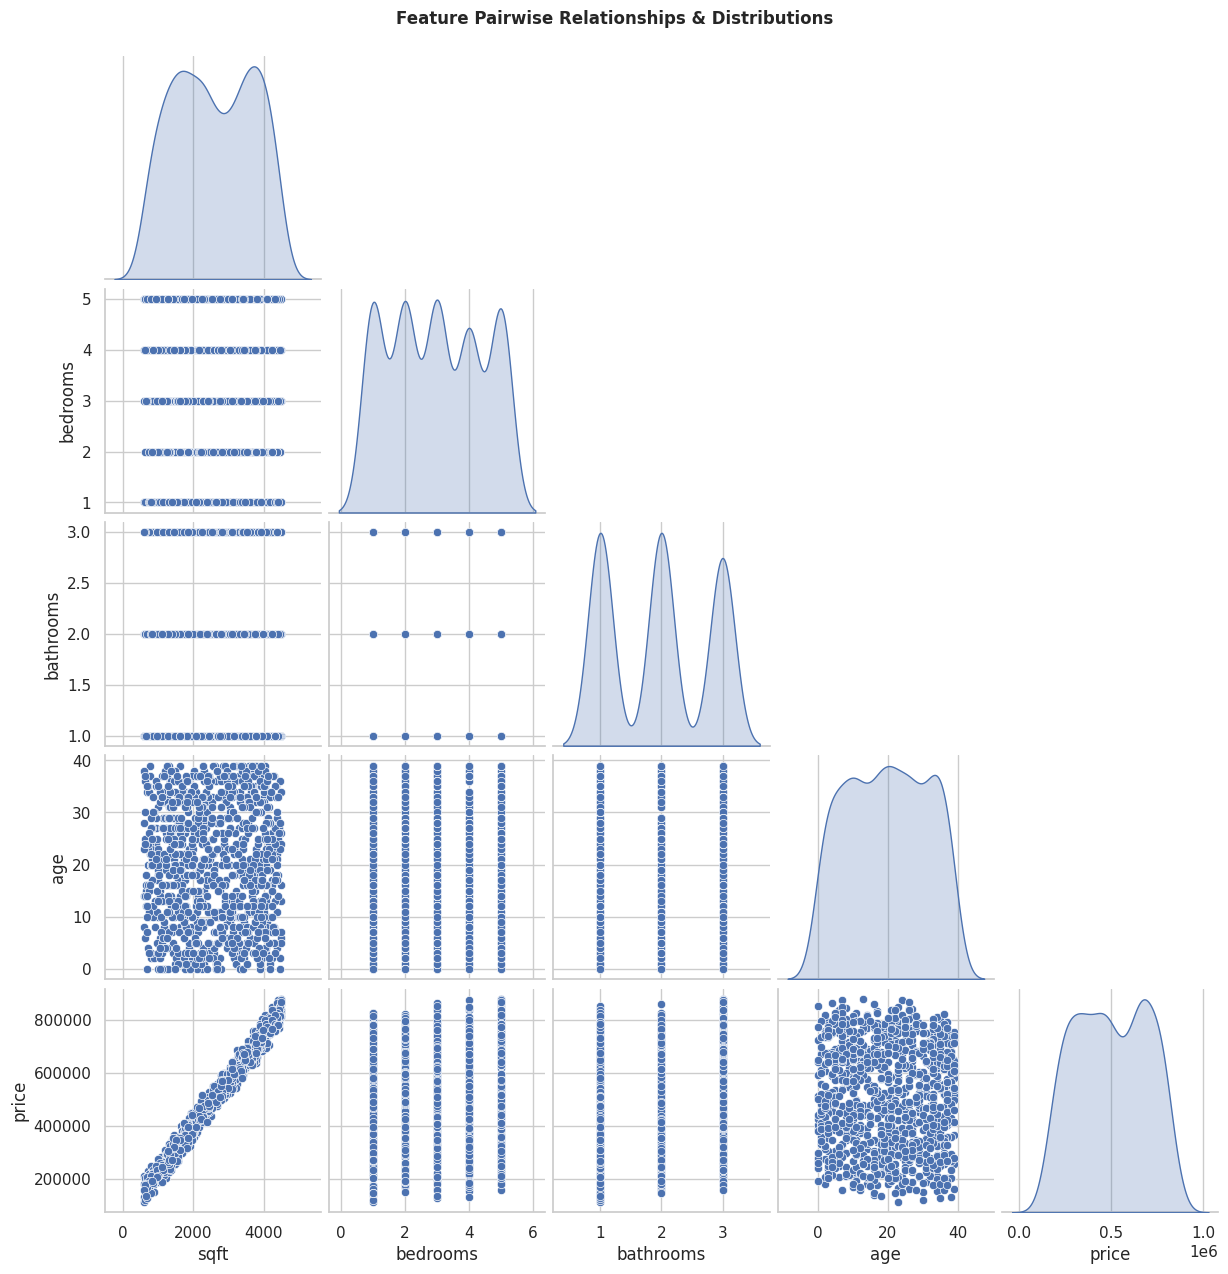


✅ Model Trained Successfully!
R² Score: 99.25%
Mean Absolute Error: $13,283.74


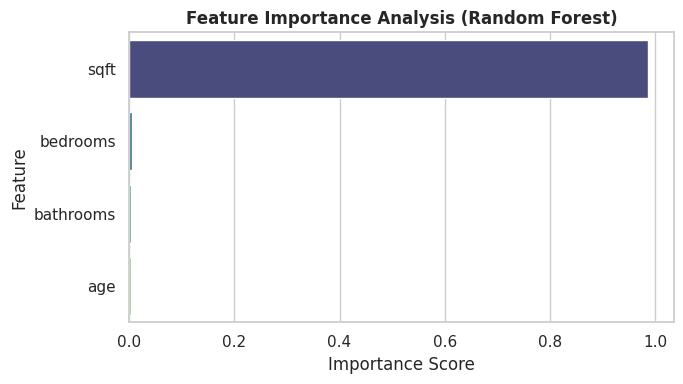

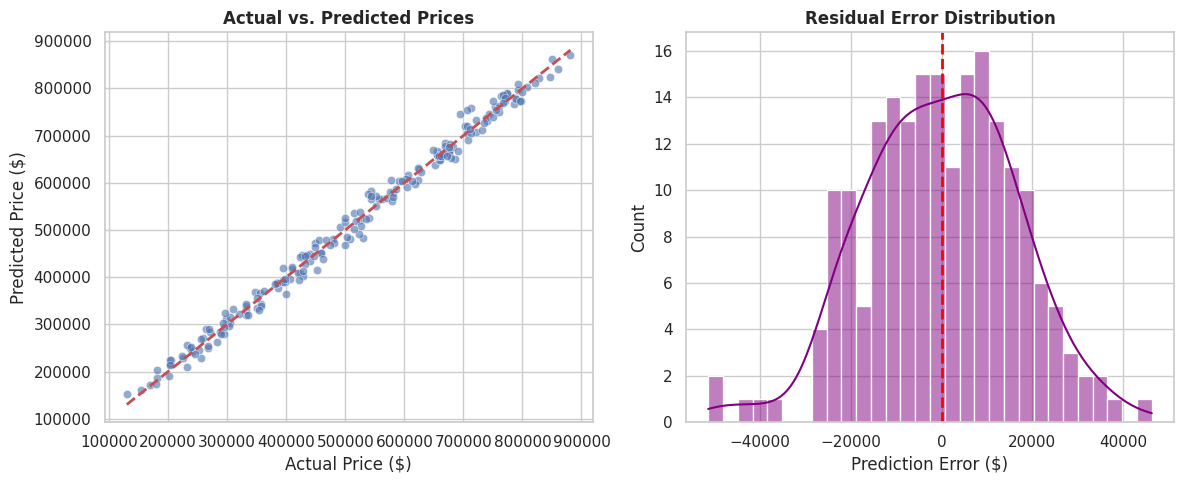

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Apply clean plotting style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. DATASET GENERATION
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 1000

sqft = np.random.randint(600, 4500, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
age = np.random.randint(0, 40, n_samples)

# Synthetic price calculation formula with variance
price = (sqft * 175) + (bedrooms * 12000) + (bathrooms * 18000) - (age * 1000) + np.random.normal(0, 10000, n_samples)

df = pd.DataFrame({'sqft': sqft, 'bedrooms': bedrooms, 'bathrooms': bathrooms, 'age': age, 'price': price})

# ---------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS
# ---------------------------------------------------------
print("📊 Generating Exploratory Data Analysis Plots...")

# Heatmap: Feature Correlation Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Pair Plot: Distributions & Inter-feature Relationships
pair_fig = sns.pairplot(df, corner=True, diag_kind="kde")
pair_fig.fig.suptitle("Feature Pairwise Relationships & Distributions", y=1.02, fontsize=12, fontweight='bold')
plt.show()

# ---------------------------------------------------------
# 3. MODEL TRAINING & EVALUATION
# ---------------------------------------------------------
X = df[['sqft', 'bedrooms', 'bathrooms', 'age']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

print("\n✅ Model Trained Successfully!")
print(f"R² Score: {r2_score(y_test, y_pred) * 100:.2f}%")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.2f}")

# ---------------------------------------------------------
# 4. FEATURE IMPORTANCE CHART
# ---------------------------------------------------------
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(7, 4))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette='viridis', legend=False)
plt.title("Feature Importance Analysis (Random Forest)", fontsize=12, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. RESIDUAL DIAGNOSTICS & MODEL ACCURACY PLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot A: Actual vs. Predicted Prices
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.6, color='b')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Actual vs. Predicted Prices", fontweight='bold')
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")

# Plot B: Residual Error Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=30)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title("Residual Error Distribution", fontweight='bold')
axes[1].set_xlabel("Prediction Error ($)")

plt.tight_layout()
plt.show()

#

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

# ---------------------------------------------------------
# HELPER: PREDICTION & DYNAMIC SENSITIVITY PLOT GENERATOR
# ---------------------------------------------------------
def predict_and_plot(sqft, bedrooms, bathrooms, age):
    # 1. Point prediction
    features = pd.DataFrame([[sqft, bedrooms, bathrooms, age]],
                            columns=['sqft', 'bedrooms', 'bathrooms', 'age'])
    predicted_price = model.predict(features)[0]

    # 2. Dynamic curve: Vary square footage while holding other inputs constant
    sqft_range = np.linspace(600, 4500, 50)
    curve_data = pd.DataFrame({
        'sqft': sqft_range,
        'bedrooms': [bedrooms] * 50,
        'bathrooms': [bathrooms] * 50,
        'age': [age] * 50
    })
    predicted_curve = model.predict(curve_data)

    # 3. Build live matplotlib plot
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.set_theme(style="whitegrid")

    # Plot sensitivity curve
    ax.plot(sqft_range, predicted_curve, color='#1f77b4', linewidth=2.5, label='Price Trend')
    # Highlight user's selected point
    ax.scatter([sqft], [predicted_price], color='#d62728', s=120, zorder=5, label='Selected Property')

    ax.set_title(f"Valuation Curve (Fixed: {bedrooms} Bed, {bathrooms} Bath, {age} y/o)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Square Footage (sq ft)", fontsize=9)
    ax.set_ylabel("Predicted Price ($)", fontsize=9)
    ax.yaxis.set_major_formatter('${x:,.0f}')
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()

    return f"${predicted_price:,.2f}", fig

# ---------------------------------------------------------
# REFINED GRADIO INTERFACE (gr.Blocks)
# ---------------------------------------------------------
custom_theme = gr.themes.Soft(primary_hue="indigo", secondary_hue="blue")

with gr.Blocks(theme=custom_theme, title="AI House Price Estimator") as demo:
    gr.Markdown(
        """
        # 🏡 AI House Price Estimator & Market Analytics
        Adjust the property attributes below to evaluate real-time valuations and view live price sensitivity trends.
        """
    )

    with gr.Row():
        # Left Column: Inputs & Preset Scenarios
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ Property Attributes")
            sqft_input = gr.Slider(600, 4500, step=50, value=1800, label="Square Footage (sq ft)")
            bedrooms_input = gr.Slider(1, 5, step=1, value=3, label="Bedrooms")
            bathrooms_input = gr.Slider(1, 4, step=1, value=2, label="Bathrooms")
            age_input = gr.Slider(0, 40, step=1, value=10, label="Property Age (Years)")

            calc_btn = gr.Button("🔍 Calculate Valuation", variant="primary")

            gr.Markdown("### 📋 Preset Scenarios")
            gr.Examples(
                examples=[
                    [1100, 2, 1, 30],  # Starter / Older Home
                    [2200, 3, 2, 12],  # Standard Suburban
                    [3200, 4, 3, 0],   # Modern Family Build
                    [4200, 5, 4, 2],   # High-End Luxury Estate
                ],
                inputs=[sqft_input, bedrooms_input, bathrooms_input, age_input],
                label="Click a preset to auto-fill inputs:"
            )

        # Right Column: Valuation & Visual Analytics
        with gr.Column(scale=1):
            gr.Markdown("### 📈 Real-Time Output")
            price_output = gr.Textbox(label="Estimated Market Value", interactive=False)
            plot_output = gr.Plot(label="Live Price Sensitivity Analysis")

    # Connect events
    inputs_list = [sqft_input, bedrooms_input, bathrooms_input, age_input]
    outputs_list = [price_output, plot_output]

    # Calculate on button click
    calc_btn.click(fn=predict_and_plot, inputs=inputs_list, outputs=outputs_list)

    # Live updates when moving sliders
    for slider in inputs_list:
        slider.change(fn=predict_and_plot, inputs=inputs_list, outputs=outputs_list)

demo.launch(share=True)

/tmp/ipykernel_1692/1351349479.py:49: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=custom_theme, title="AI House Price Estimator") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://37d4e9fb181fe04803.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
